# Capturing Non-Linearity Using Polynomial Regression

## Objective

The goal of this notebook is to check whether the Advertising dataset contains non-linear patterns and to see how Polynomial Regression can improve the model performance.

## Motivation

In the baseline Linear Regression notebook, the residual plots showed that the model was not able to capture all patterns in the data perfectly.

This suggests that some non-linear relationships may exist between advertising spending and sales.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# load dataset
data = pd.read_csv('/content/drive/My Drive/Advertising.csv')
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


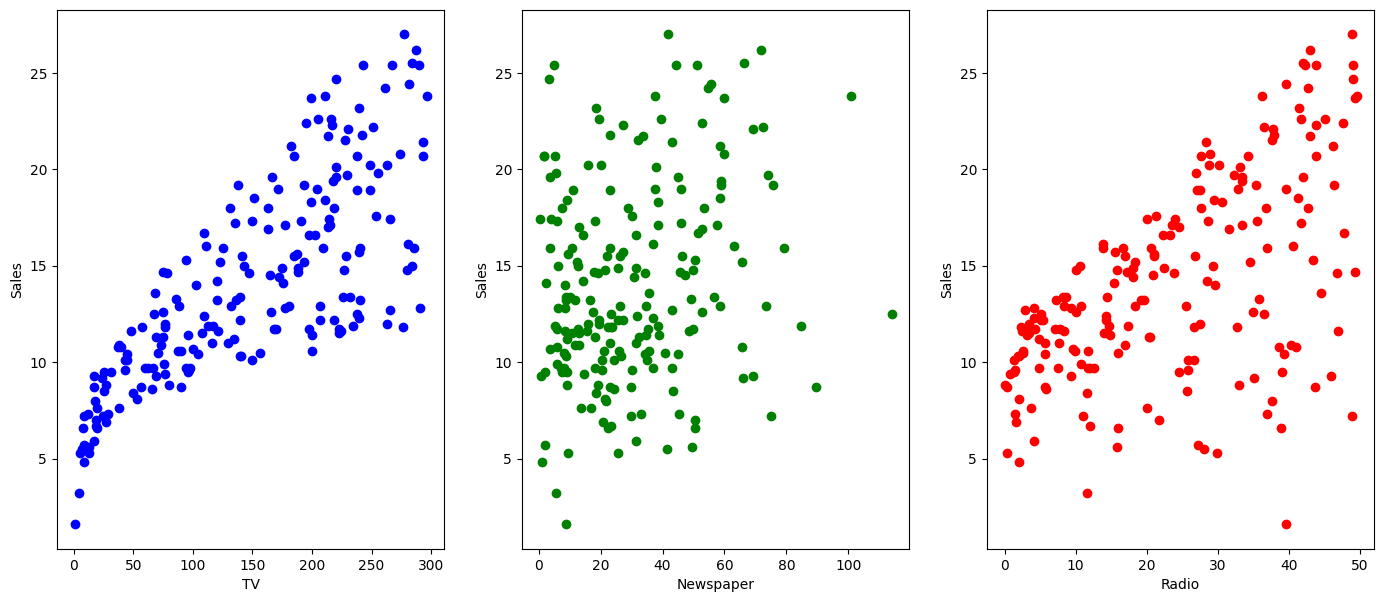

In [6]:
# linearity analysis
fig, ax = plt.subplots(1, 3, figsize=(17, 7))

ax[0].scatter(data['TV'], data['Sales'], color='b')
ax[0].set_xlabel('TV')
ax[0].set_ylabel('Sales')

ax[1].scatter(data['Newspaper'], data['Sales'], color='g')
ax[1].set_xlabel('Newspaper')
ax[1].set_ylabel('Sales')

ax[2].scatter(data['Radio'], data['Sales'], color='r')
ax[2].set_xlabel('Radio')
ax[2].set_ylabel('Sales')

plt.show()

Scatter plots between individual advertising platforms and Sales show that TV and Radio advertising have a relatively positive linear relationship with Sales. In contrast, the Newspaper feature shows a weaker and less clear linear relationship with the target variable.

In [7]:
X = data[['TV', 'Newspaper', 'Radio']]
y = data['Sales']

In [8]:
# Linear Regression
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# train model
lr.fit(x_train, y_train)

LinearRegression()

In [9]:
y_pred = lr.predict(x_test)

In [10]:
# metrics
from sklearn.metrics import mean_squared_error, r2_score

print(f'Root Mean Squared Error -> {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2 Score -> {r2_score(y_test, y_pred)}')

Root Mean Squared Error -> 1.9485372043446378
R2 Score -> 0.8609466508230369


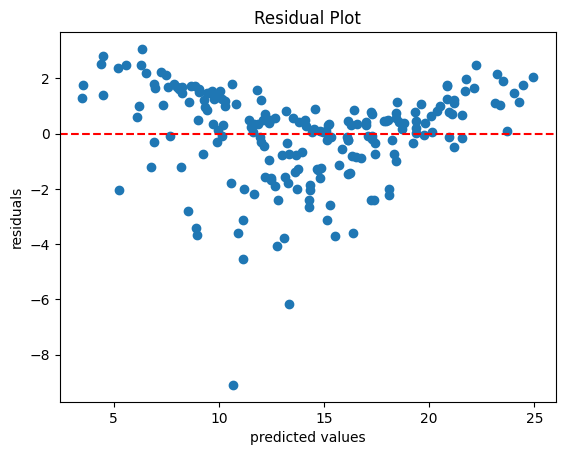

In [11]:
# residual plot
y_pred_full = lr.predict(X)

plt.scatter(y_pred_full, y-y_pred_full)
plt.axhline(y=0, color='r', linestyle='--')

plt.title('Residual Plot')
plt.xlabel('predicted values')
plt.ylabel('residuals')
plt.show()

## Residual Analysis of Baseline Model

The residual plot from the baseline model showed visible patterns instead of completely random scatter.

This indicates that the model may not fully capture the relationship between advertising spending and sales.

## Applying Polynomial Regression

Polynomial Regression adds higher-order features to the dataset, which allows the model to capture curved and more complex relationships.

Although the final model is still Linear Regression, the transformed polynomial features increase the flexibility of the model.

In [12]:
# Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3, include_bias=False)

x_train_transform = poly.fit_transform(x_train)
x_test_transform = poly.transform(x_test)

In [13]:
print("Original features shape:", x_train.shape)
print("Polynomial features shape:", x_train_transform.shape)

Original features shape: (140, 3)
Polynomial features shape: (140, 19)


In [14]:
# all polynomial features
poly.get_feature_names_out()

array(['TV', 'Newspaper', 'Radio', 'TV^2', 'TV Newspaper', 'TV Radio',
       'Newspaper^2', 'Newspaper Radio', 'Radio^2', 'TV^3',
       'TV^2 Newspaper', 'TV^2 Radio', 'TV Newspaper^2',
       'TV Newspaper Radio', 'TV Radio^2', 'Newspaper^3',
       'Newspaper^2 Radio', 'Newspaper Radio^2', 'Radio^3'], dtype=object)

In [15]:

# train model
lr.fit(x_train_transform, y_train)

LinearRegression()

In [16]:
y_pred_poly = lr.predict(x_test_transform)

In [17]:
print(f'Root Mean Squared Error -> {np.sqrt(mean_squared_error(y_test, y_pred_poly))}')
print(f'R2 Score -> {r2_score(y_test, y_pred_poly)}')

Root Mean Squared Error -> 0.5392350985663785
R2 Score -> 0.9893507173596437


## Polynomial Regression Performance

After applying Polynomial Regression with degree 3, the R² score improved significantly and RMSE decreased.

This suggests that the polynomial model was able to capture some non-linear behavior that the baseline Linear Regression model could not capture.

In [18]:
print("Train R2:", r2_score(y_train, lr.predict(x_train_transform)))

print("Test R2:", r2_score(y_test, y_pred_poly))

Train R2: 0.991622095396409
Test R2: 0.9893507173596437


## Why Compare Train and Test R² Scores?

Checking both train and test R² scores helps us understand whether the model is learning useful patterns or simply memorizing the training data.

- Train R² shows how well the model fits the training data.
- Test R² shows how well the model performs on unseen data.

If the train R² is very high but the test R² is much lower, the model is likely overfitting and not generalizing well.

Here both train and test R² scores are high and reasonably close, which suggests that the Polynomial Regression model generalizes well and captures meaningful patterns from the dataset.

# Performance Comparison

| Model | Train R² | Test R² | RMSE |
|---|---|---|---|
| Linear Regression | 0.90 | 0.86 | 1.92 |
| Polynomial Regression | 0.99 | 0.98 | 0.53 |

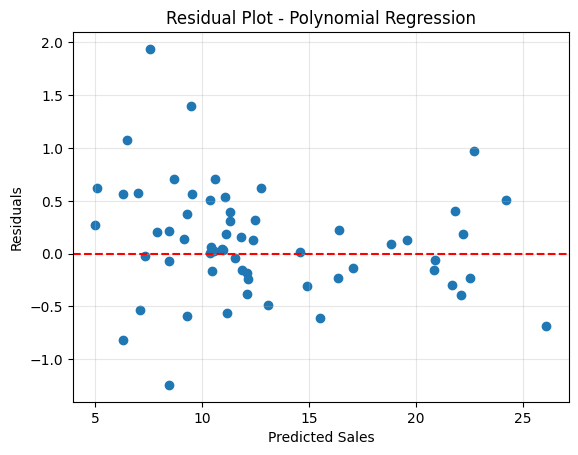

In [ ]:
# plotting residuals
residuals_poly = y_test - y_pred_poly

plt.scatter(y_pred_poly, residuals_poly)

plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot - Polynomial Regression")

plt.grid(alpha=0.3)

plt.show()

## Residual Analysis After Polynomial Regression

Compared to the baseline Linear Regression model, the residuals after Polynomial Regression appear more randomly scattered around zero.

The earlier systematic patterns visible in the baseline residual plot are reduced, which suggests that the polynomial model captures some of the non-linear behavior present in the dataset more effectively.

Although some spread and outliers still remain, the overall residual behavior indicates an improved model fit.

# Final Insight

The baseline Linear Regression model already performed well on the Advertising dataset, but residual analysis suggested that some non-linear patterns were still present.

Polynomial Regression improved the model by capturing some of these non-linear relationships, which increased the R² score and improved residual behavior.

However, when I earlier used very high polynomial degrees, it made the model overly complex and caused overfitting, showing that model complexity should always be controlled carefully.